# RL Group Project: Configuration B
## Clinical Treatment Optimisation: Sepsis ICU Management — Continuous Observations + Creative Extension

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This notebook covers **Configuration B**, where the agent operates in the full continuous-observation ICU-Sepsis environment with three clinical reality wrappers injecting realistic failure modes.

Additionally, we add a creative extension where we measure policy agreement and create an ensemble decision-making.

---
### Group Members

Name of the Group: Group AB

```
Student 1: Andreea Roica
Student 2: Marisa Esteves
Student 3: Miguel Caramelo
Student 4: Oliver Kain
```

## 0. Setup & Imports

In [1]:
# Install dependencies (run once if needed)
# !pip install icu-sepsis numpy pandas matplotlib seaborn torch gymnasium optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
import torch
import optuna

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

import importlib
import rl_configB_functions
importlib.reload(rl_configB_functions)

from rl_configB_functions import (
    # constants
    SEED, N_OBS, N_ACTIONS, GAMMA,
    # evaluation
    EvalMetricsB, evaluate_policy_b, evaluate_policy_multiseed,
    # networks
    QNetwork, ActorCritic, ReplayBuffer,
    # agents
    DQNAgent, PPOAgent,
    # training
    train_dqn, train_ppo,
    # tuning
    run_optuna,
    # plotting
    moving_average, plot_return_curves, plot_survival_curves,
    dqn_convergence_episode,
)

from envs.wrappers import make_clinical_env

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots',       exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
PLOTS_DIR = 'plots'

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print(f'Config B | Obs dim: {N_OBS} | Actions: {N_ACTIONS} | γ = {GAMMA}')
print(f'PyTorch  : {torch.__version__}')
print(f'Optuna   : {optuna.__version__}')
print('Setup complete!')

Config B | Obs dim: 47 | Actions: 25 | γ = 1.0
PyTorch  : 2.12.0
Optuna   : 4.8.0
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---
## 1. Explore the Clinical Environment



Before designing any algorithm we inspect the environment structure, understand the
47-dimensional observation space, and establish a random-policy baseline.

In [2]:
env = make_clinical_env()
obs, info = env.reset(seed=SEED)

print('Clinical ICU-Sepsis environment')
print(f'  Observation space : {env.observation_space}')
print(f'  Action space      : {env.action_space}')
print(f'  Obs shape         : {obs.shape}  dtype={obs.dtype}')
print(f'  Info keys         : {list(info.keys())}')
print()
print('Wrapper stack (outermost first):')
e = env
while hasattr(e, 'env'):
    print(f'  {type(e).__name__}')
    e = e.env
print(f'  {type(e).__name__}  (base environment) base environment')
env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical ICU-Sepsis environment
  Observation space : Box(-inf, inf, (47,), float32)
  Action space      : Discrete(25)
  Obs shape         : (47,)  dtype=float32
  Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

Wrapper stack (outermost first):
  AcuteEventEnv
  EpisodicMissingObsEnv
  EpisodicNoisyObsEnv
  ContinuousICUSepsisEnv  (base environment) base environment


In [3]:
from envs.continuous_sepsis_env import FEATURE_NAMES

feat_df = pd.DataFrame({'index': range(len(FEATURE_NAMES)), 'feature': FEATURE_NAMES})
print(f'Physiological feature vector ({len(FEATURE_NAMES)} dimensions):')
print(feat_df.to_string(index=False))

Physiological feature vector (47 dimensions):
 index        feature
     0        Albumin
     1            ALP
     2            ALT
     3            AST
     4      Bilirubin
     5            BUN
     6       Chloride
     7     Creatinine
     8   Diastolic_BP
     9     Fibrinogen
    10           FiO2
    11            GCS
    12        Glucose
    13           HCO3
    14     Hemoglobin
    15            INR
    16        Lactate
    17          MgSO4
    18        Mean_BP
    19      Potassium
    20            PTT
    21          PaCO2
    22           PaO2
    23      Platelets
    24            RBC
    25           SOFA
    26         Sodium
    27    Systolic_BP
    28    Temperature
    29       Troponin
    30   Urine_Output
    31            WBC
    32         Weight
    33             Ca
    34        Heparin
    35             HR
    36      Na_Bicarb
    37        Insulin
    38 Norepinephrine
    39       Propofol
    40    Vasopressin
    41       Dopamine
    42  

### Random baseline

Evaluate a purely random policy over 50 000 episodes across 5 random seeds to establish a lower-bound performance reference.

All trained agents must beat this baseline on survival rate and mean return.

In [4]:
RANDOM_BASELINE_SEEDS = [101, 202, 303, 404, 505]
RANDOM_BASELINE_EPISODES_PER_SEED = 50000

random_seed_summaries = []

clinical_rand_returns = []
noisy_returns, clean_returns    = [], []
missing_returns, nomiss_returns = [], []
acute_returns, noacute_returns = [], []

for eval_seed in RANDOM_BASELINE_SEEDS:
    np.random.seed(eval_seed)

    seed_returns = []

    env_eval = make_clinical_env()

    for ep in range(RANDOM_BASELINE_EPISODES_PER_SEED):
        obs, info = env_eval.reset(seed=int(np.random.randint(100000)))
        total_r, done = 0.0, False

        ep_noisy   = info.get("noisy_episode", False)
        ep_missing = info.get("missing_features") is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r
            done = te or tr

            if info.get("acute_event", False):
                ep_acute = True

        seed_returns.append(total_r)
        clinical_rand_returns.append(total_r)

        (noisy_returns if ep_noisy else clean_returns).append(total_r)
        (missing_returns if ep_missing else nomiss_returns).append(total_r)
        (acute_returns if ep_acute else noacute_returns).append(total_r)

    env_eval.close()

    seed_returns = np.array(seed_returns)

    random_seed_summaries.append({
        "seed": eval_seed,
        "mean_return": float(seed_returns.mean()),
        "survival_rate": float((seed_returns > 0).mean()),
    })

random_baseline_df = pd.DataFrame(random_seed_summaries)

clinical_rand_mean = float(random_baseline_df["mean_return"].mean())
clinical_rand_std = float(random_baseline_df["mean_return"].std(ddof=1))

clinical_rand_surv = float(random_baseline_df["survival_rate"].mean())
clinical_rand_surv_std = float(random_baseline_df["survival_rate"].std(ddof=1))

print(
    f"\n\n=== Random Baseline "
    f"({len(RANDOM_BASELINE_SEEDS)} seeds x "
    f"{RANDOM_BASELINE_EPISODES_PER_SEED} episodes) ==="
)
print(f"Overall mean return: {clinical_rand_mean:.4f} ± {clinical_rand_std:.4f}")
print(f"Overall survival rate : {clinical_rand_surv:.1%} ± {clinical_rand_surv_std:.1%}")
print()

print("Per-seed summary:")
display(random_baseline_df.round({"mean_return": 4,"survival_rate": 4,}))

print()
print("Stratified by wrapper:")
print(f"Noisy     ({len(noisy_returns):5d} eps) return={np.mean(noisy_returns):.4f}  surv={np.mean(np.array(noisy_returns) > 0):.1%}")
print(f"Clean     ({len(clean_returns):5d} eps) return={np.mean(clean_returns):.4f}  surv={np.mean(np.array(clean_returns) > 0):.1%}")
print(f"Missing   ({len(missing_returns):5d} eps) return={np.mean(missing_returns):.4f}  surv={np.mean(np.array(missing_returns) > 0):.1%}")
print(f"Complete  ({len(nomiss_returns):5d} eps) return={np.mean(nomiss_returns):.4f}  surv={np.mean(np.array(nomiss_returns) > 0):.1%}")
print(f"Acute     ({len(acute_returns):5d} eps) return={np.mean(acute_returns):.4f}  surv={np.mean(np.array(acute_returns) > 0):.1%}")
print(f"Not acute ({len(noacute_returns):5d} eps) return={np.mean(noacute_returns):.4f}  surv={np.mean(np.array(noacute_returns) > 0):.1%}")

print()
print("All trained agents must beat this baseline.")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


=== Random Baseline (5 seeds x 50000 episodes) ===
Overall mean return: 0.5607 ± 0.0011
Overall survival rate : 65.3% ± 0.1%

Per-seed summary:


,seed,mean_return,survival_rate
0,101,0.5596,0.6528
1,202,0.5617,0.6533
2,303,0.5599,0.6521
3,404,0.5620,0.6545
4,505,0.5601,0.6533



Stratified by wrapper:
Noisy     (37742 eps) return=0.5622  surv=65.5%
Clean     (212258 eps) return=0.5604  surv=65.3%
Missing   (37513 eps) return=0.5604  surv=65.2%
Complete  (212487 eps) return=0.5607  surv=65.3%
Acute     (21173 eps) return=-0.0872  surv=0.0%
Not acute (228827 eps) return=0.6206  surv=71.4%

All trained agents must beat this baseline.


---
## 2. Experimental Configuration



### Why Double DQN?

With a 47-dimensional continuous observation space a Q-table is infeasible.
DQN uses a neural network to approximate $Q(s,a)$ across the continuous state
space. Two key stabilisation mechanisms address the instabilities of training
neural networks with RL objectives:

1. **Experience Replay** — transitions are stored in a buffer and sampled
   uniformly at random, breaking the temporal correlation of consecutive
   samples. The **buffer size** controls how much old experience is retained.
2. **Target Network** — a periodically-synced copy provides stable bootstrap
   targets, avoiding the moving-target problem. The **target update frequency**
   controls the lag between the online and target networks.

**Double DQN** further decouples action *selection* (online network) from
action *evaluation* (target network), reducing Q-value overestimation.

### Why PPO?

PPO is an on-policy policy-gradient method. It has **no replay buffer and no
target network**. It collects fresh rollouts with the current policy, computes
GAE advantages, and performs several clipped-objective update epochs before
discarding the data. This makes it a strong comparison point: we can see
whether value-based off-policy methods are better suited to this environment
than on-policy policy-gradient methods.

In [5]:
# --- evaluation seeds used for tuning and training ---
EVAL_SEEDS = RANDOM_BASELINE_SEEDS.copy() # the seeds need to be the same for the random baseline and the trained agents to ensure a fair comparison

# --- training budgets ---
N_EPISODES = 50000

# --- Optuna tuning budgets (kept small relative to the final run) ---
N_TRIALS          = 20
N_EPISODES_TUNE    = 10000
EVAL_EPISODES_TUNE = 10000

# --- evaluation budget ---
EVAL_EPISODES = 50000

# --- learning-curve smoothing window ---
MA_WINDOW = 500

print(f'Training episodes: {N_EPISODES:,}')
print(f'Optuna trials    : {N_TRIALS} x {N_EPISODES_TUNE} episodes')
print(f'Eval episodes    : {EVAL_EPISODES}')
print(f'MA window        : {MA_WINDOW}')

Training episodes: 50,000
Optuna trials    : 20 x 10000 episodes
Eval episodes    : 50000
MA window        : 500


---
## 3. Hyperparameter Search with Optuna



We use Optuna  to search for good hyperparameters for each algorithm
on a small episode budget. The best parameters found are then used for the full
50 000-episode run.

### 3a. Optuna — Double DQN

In [6]:
# --- Optuna search DISABLED: reusing the recovered best hyperparameters ---
# The expensive search is commented out. We plug in the DDQN configuration that
# reached ~73% survival mid-training, and the train_dqn best-checkpoint now keeps
# that peak. The Optuna analysis tables are reloaded from the saved workbook so
# the rest of the notebook still runs.
#
# best_params_ddqn, study_ddqn = run_optuna(
#     'ddqn', n_trials=N_TRIALS, n_episodes_tune=N_EPISODES_TUNE,
#     eval_episodes=EVAL_EPISODES_TUNE, eval_seeds=EVAL_SEEDS,
#     metric='combined', seed=SEED, verbose=True,
# )

best_params_ddqn = {
    'lr': 0.000267775333103133,
    'exploration_fraction': 0.05,
    'epsilon_min': 0.05,
    'batch_size': 128,
    'buffer_size': 100000,
    'target_update_freq': 50,
    'gradient_steps': 2,
    'hidden1': 128,
    'hidden2': 128,
}

# Reuse the Optuna result tables from the saved workbook (no re-tuning).
ddqn_pareto_df = pd.read_excel('ddqn_ppo_results.xlsx', sheet_name='DDQN Pareto')
ddqn_trials_df = pd.read_excel('ddqn_ppo_results.xlsx', sheet_name='DDQN Trials')
display(ddqn_pareto_df)

print('Double DQN best params (reused):', best_params_ddqn)
print(f"  -> buffer_size        = {best_params_ddqn['buffer_size']}")
print(f"  -> target_update_freq = {best_params_ddqn['target_update_freq']}")

,survival_rate,mean_return,net_arch,lr,exploration_fraction,epsilon_min,batch_size,buffer_size,target_update_freq,gradient_steps
0,0.728,0.665535,64,0.000107,0.1,0.05,32,100000,100,4


Double DQN best params (reused): {'lr': 0.000267775333103133, 'exploration_fraction': 0.05, 'epsilon_min': 0.05, 'batch_size': 128, 'buffer_size': 100000, 'target_update_freq': 50, 'gradient_steps': 2, 'hidden1': 128, 'hidden2': 128}
  -> buffer_size        = 100000
  -> target_update_freq = 50


In [7]:
# Optuna trial summary table — Double DQN (reused from saved results)
display(ddqn_trials_df.head(10).round(5))

print('\nbuffer_size vs. mean return (Double DQN):')
print(ddqn_trials_df.groupby('buffer_size')['mean_return'].mean().round(4))

print('\nbuffer_size vs. survival rate (Double DQN):')
print(ddqn_trials_df.groupby('buffer_size')['survival_rate'].mean().round(4))

print('\ntarget_update_freq vs. mean return (Double DQN):')
print(ddqn_trials_df.groupby('target_update_freq')['mean_return'].mean().round(4))

print('\ntarget_update_freq vs. survival rate (Double DQN):')
print(ddqn_trials_df.groupby('target_update_freq')['survival_rate'].mean().round(4))

,net_arch,lr,exploration_fraction,epsilon_min,batch_size,buffer_size,target_update_freq,gradient_steps,survival_rate,mean_return
0,64,0.00011,0.10,0.05,32,100000,100,4,0.728,0.66554
1,64,0.00225,0.05,0.05,64,10000,50,1,0.692,0.63344
2,256,0.00179,0.10,0.10,64,50000,250,2,0.678,0.61826
3,64,0.00036,0.20,0.01,64,10000,100,2,0.678,0.59124
4,128,0.00014,0.05,0.10,64,100000,100,2,0.668,0.58884
5,128,0.00104,0.05,0.01,64,10000,100,1,0.666,0.60636
6,256,0.00088,0.05,0.05,128,10000,500,1,0.666,0.58994
7,256,0.00038,0.05,0.05,32,50000,100,2,0.664,0.59236
8,256,0.00389,0.05,0.05,64,50000,500,1,0.662,0.59551
9,256,0.00022,0.10,0.01,64,100000,250,1,0.662,0.57082



buffer_size vs. mean return (Double DQN):
buffer_size
10000     0.5867
50000     0.5729
100000    0.5909
Name: mean_return, dtype: float64

buffer_size vs. survival rate (Double DQN):
buffer_size
10000     0.6575
50000     0.6553
100000    0.6687
Name: survival_rate, dtype: float64

target_update_freq vs. mean return (Double DQN):
target_update_freq
50     0.5772
100    0.6039
250    0.5854
500    0.5685
Name: mean_return, dtype: float64

target_update_freq vs. survival rate (Double DQN):
target_update_freq
50     0.6532
100    0.6747
250    0.6633
500    0.6500
Name: survival_rate, dtype: float64


### 3b. Optuna — PPO

In [8]:
# --- Optuna search DISABLED: reusing the recovered best hyperparameters ---
# best_params_ppo, study_ppo = run_optuna(
#     'ppo', n_trials=N_TRIALS, n_episodes_tune=N_EPISODES_TUNE,
#     eval_episodes=EVAL_EPISODES_TUNE, eval_seeds=EVAL_SEEDS,
#     metric='combined', seed=SEED, verbose=True,
# )

best_params_ppo = {
    'lr': 0.00010900492537293822,
    'gae_lambda': 0.9,
    'clip_eps': 0.1,
    'entropy_coef': 0.05,
    'value_coef': 0.5,
    'rollout_length': 512,
    'update_epochs': 4,
    'minibatch_size': 256,
    'hidden1': 128,
    'hidden2': 128,
}

ppo_pareto_df = pd.read_excel('ddqn_ppo_results.xlsx', sheet_name='PPO Pareto')
ppo_trials_df = pd.read_excel('ddqn_ppo_results.xlsx', sheet_name='PPO Trials')
display(ppo_pareto_df)

print('PPO best params (reused):', best_params_ppo)
print(f"  -> rollout_length        = {best_params_ppo['rollout_length']}")
print(f"  -> clip_eps = {best_params_ppo['clip_eps']}")
print(f"  -> gae_lambda  = {best_params_ppo['gae_lambda']}")
print(f"  -> ent_coef = {best_params_ppo['entropy_coef']}")

,survival_rate,mean_return,lr,gae_lambda,clip_eps,entropy_coef,value_coef,rollout_length,update_epochs,minibatch_size,hidden1,hidden2
0,0.716,0.65558,0.000357,0.9,0.1,0.00,1.0,512,10,64,64,256
1,0.714,0.65709,0.000109,0.9,0.1,0.05,0.5,512,4,256,128,128


PPO best params (reused): {'lr': 0.00010900492537293822, 'gae_lambda': 0.9, 'clip_eps': 0.1, 'entropy_coef': 0.05, 'value_coef': 0.5, 'rollout_length': 512, 'update_epochs': 4, 'minibatch_size': 256, 'hidden1': 128, 'hidden2': 128}
  -> rollout_length        = 512
  -> clip_eps = 0.1
  -> gae_lambda  = 0.9
  -> ent_coef = 0.05


In [9]:
# Optuna trial summary table — PPO (reused from saved results)
display(ppo_trials_df.head(10).round(5))

print('\nclip_eps vs. mean return (PPO):')
print(ppo_trials_df.groupby('clip_eps')['mean_return'].mean().round(4))

print('\nclip_eps vs. survival rate (PPO):')
print(ppo_trials_df.groupby('clip_eps')['survival_rate'].mean().round(4))

print('\ngae_lambda vs. mean return (PPO):')
print(ppo_trials_df.groupby('gae_lambda')['mean_return'].mean().round(4))

print('\ngae_lambda vs. survival rate (PPO):')
print(ppo_trials_df.groupby('gae_lambda')['survival_rate'].mean().round(4))

print('\nentropy_coef vs. survival rate (PPO):')
print(ppo_trials_df.groupby('entropy_coef')['survival_rate'].mean().round(4))

print('\nrollout_length vs. survival rate (PPO):')
print(ppo_trials_df.groupby('rollout_length')['survival_rate'].mean().round(4))

,lr,gae_lambda,clip_eps,entropy_coef,value_coef,rollout_length,update_epochs,minibatch_size,hidden1,hidden2,survival_rate,mean_return
0,0.00036,0.90,0.1,0.00,1.0,512,10,64,64,256,0.716,0.65558
1,0.00011,0.90,0.1,0.05,0.5,512,4,256,128,128,0.714,0.65709
2,0.00041,1.00,0.1,0.05,0.5,512,10,64,64,128,0.702,0.61892
3,0.00050,0.95,0.2,0.01,1.0,1024,4,64,64,64,0.690,0.63546
4,0.00219,1.00,0.3,0.01,1.0,2048,10,64,256,64,0.686,0.58994
5,0.00290,1.00,0.2,0.05,1.0,1024,4,128,256,128,0.684,0.59728
6,0.00027,1.00,0.1,0.05,1.0,512,4,256,128,256,0.680,0.60426
7,0.00232,0.90,0.1,0.05,0.5,2048,4,64,128,256,0.678,0.60883
8,0.00049,1.00,0.3,0.05,0.5,512,10,256,256,128,0.678,0.58589
9,0.00010,1.00,0.3,0.05,1.0,512,4,128,64,128,0.676,0.60956



clip_eps vs. mean return (PPO):
clip_eps
0.1    0.6054
0.2    0.5944
0.3    0.5890
Name: mean_return, dtype: float64

clip_eps vs. survival rate (PPO):
clip_eps
0.1    0.6740
0.2    0.6660
0.3    0.6644
Name: survival_rate, dtype: float64

gae_lambda vs. mean return (PPO):
gae_lambda
0.90    0.6143
0.95    0.5887
1.00    0.5935
Name: mean_return, dtype: float64

gae_lambda vs. survival rate (PPO):
gae_lambda
0.90    0.6767
0.95    0.6588
1.00    0.6709
Name: survival_rate, dtype: float64

entropy_coef vs. survival rate (PPO):
entropy_coef
0.00    0.6650
0.01    0.6560
0.05    0.6796
Name: survival_rate, dtype: float64

rollout_length vs. survival rate (PPO):
rollout_length
512     0.6815
1024    0.6586
2048    0.6660
Name: survival_rate, dtype: float64


### 3c. Optuna — Summary

In [10]:
# Optuna tuning summary 

ddqn_selected = ddqn_pareto_df.iloc[0]
ppo_selected = ppo_pareto_df.iloc[0]

print('Optuna tuning summary')
print(
    f"  Double DQN selected: survival={ddqn_selected['survival_rate']:.4f} | "
    f"return={ddqn_selected['mean_return']:.4f} | "
    f"Pareto trials={len(ddqn_pareto_df)}"
)
print(
    f"  PPO        selected: survival={ppo_selected['survival_rate']:.4f} | "
    f"return={ppo_selected['mean_return']:.4f} | "
    f"Pareto trials={len(ppo_pareto_df)}"
)

Optuna tuning summary
  Double DQN selected: survival=0.7280 | return=0.6655 | Pareto trials=1
  PPO        selected: survival=0.7160 | return=0.6556 | Pareto trials=2


---
## 4. Final Training (up to 50 000 episodes)



Each agent is trained with its Optuna-selected hyperparameters for the full
episode budget. 
The `verbose=True` flag prints a progress line every 5 000 episodes.

### 4a. Final training — Double DQN

In [11]:
hist_ddqn = train_dqn(
    n_episodes=N_EPISODES,
    double=True,
    seed=SEED,
    verbose=True,
    log_every=max(1, N_EPISODES // 10),
    **best_params_ddqn,
)

agent_ddqn = hist_ddqn['agent']
print(f"\nDouble DQN done  | buffer_size={best_params_ddqn['buffer_size']} "
      f"| target_update_freq={best_params_ddqn['target_update_freq']}")

torch.save(agent_ddqn.online_net.state_dict(), 'checkpoints/ddqn_configB.pt')
print('Checkpoint saved: checkpoints/ddqn_configB.pt')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Double DQN] new best checkpoint @ ep 2000: survival=67.40% | return=0.5919
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Double DQN] new best checkpoint @ ep 4000: survival=69.70% | return=0.6127
[Double DQN] Ep   5000/50000 | Return 0.579 | Survival 66.52% | ε=0.0500 | buffer= 45743
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[Double DQN] Ep  10000/50000 | Return 0.575 | Survival 66.10% | ε=0.0500 | buffer= 92147
make_sepsi

### 4b. Final training — PPO

In [12]:
hist_ppo = train_ppo(
    n_episodes=N_EPISODES,
    seed=SEED,
    verbose=True,
    log_every=max(1, N_EPISODES // 10),
    **best_params_ppo,
)

agent_ppo = hist_ppo['agent']
upd = hist_ppo['ppo_updates']
if upd['policy_loss']:
    print(f"\nPPO done | last update: p_loss={upd['policy_loss'][-1]:.4f} "
          f"v_loss={upd['value_loss'][-1]:.4f} "
          f"entropy={upd['entropy'][-1]:.3f} "
          f"clip={upd['clip_fraction'][-1]:.3f}")

torch.save(agent_ppo.net.state_dict(), 'checkpoints/ppo_configB.pt')
print('Checkpoint saved: checkpoints/ppo_configB.pt')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[PPO] new best checkpoint @ ep 2000: survival=66.60% | return=0.5699
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[PPO] Ep   5000/50000 | Return 0.570 | Survival 66.10% | p_loss=-0.0055 entropy=3.114
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[PPO] new best checkpoint @ ep 6000: survival=67.70% | return=0.6190
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[PPO] Ep  10000/50000 | Return 0.577 | Survival 66.38% | p_loss=-0.0040 entropy=3.082
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → i

---
## 5. Learning Curves



Two focused plots comparing Double DQN and PPO 
on the same figure over the full training run:

1. **Episode return** — did the agent learn to accumulate higher reward?
2. **Survival rate** — is the agent keeping patients alive more often?

All curves use a causal moving average of window `MA_WINDOW` (preserves
episode alignment) and include the random-policy baseline for reference.

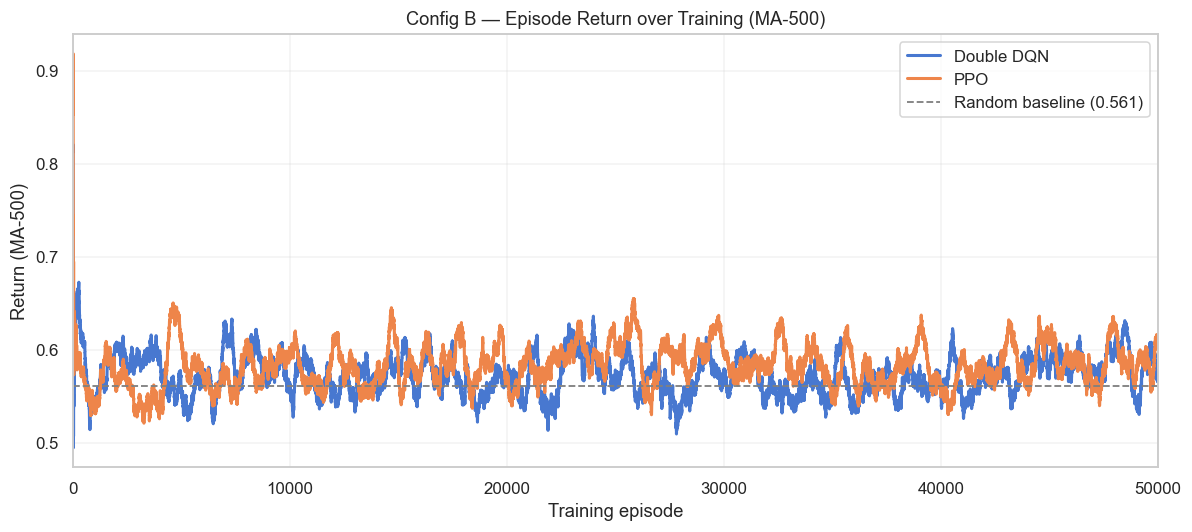

In [13]:
histories = {
    'Double DQN': hist_ddqn,
    'PPO':        hist_ppo,
}
baselines = {
    f'Random baseline ({clinical_rand_mean:.3f})': clinical_rand_mean,
}

plot_return_curves(
    histories,
    window=MA_WINDOW,
    title=f'Config B — Episode Return over Training (MA-{MA_WINDOW})',
    baselines=baselines,
    max_episodes=N_EPISODES,
    savepath=f'{PLOTS_DIR}/configB_returns.png',
)

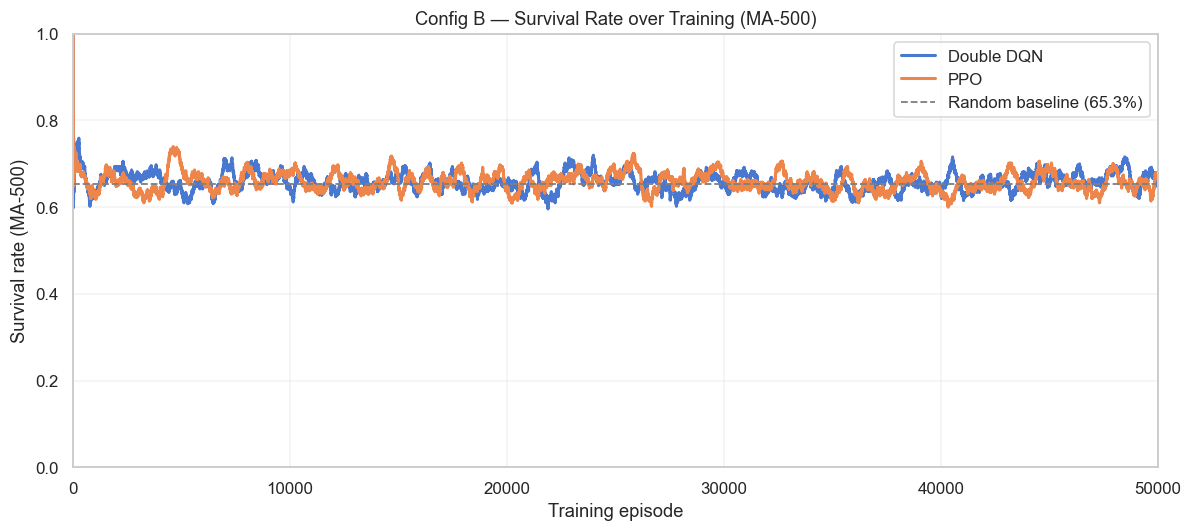

In [14]:
baselines_surv = {
    f'Random baseline ({clinical_rand_surv:.1%})': clinical_rand_surv,
}

plot_survival_curves(
    histories,
    window=MA_WINDOW,
    title=f'Config B — Survival Rate over Training (MA-{MA_WINDOW})',
    baselines=baselines_surv,
    max_episodes=N_EPISODES,
    savepath=f'{PLOTS_DIR}/configB_survival.png',
)

A plot comparing the training loss curves of the two algorithms with the best hyperparameters (Double DQN and PPO).

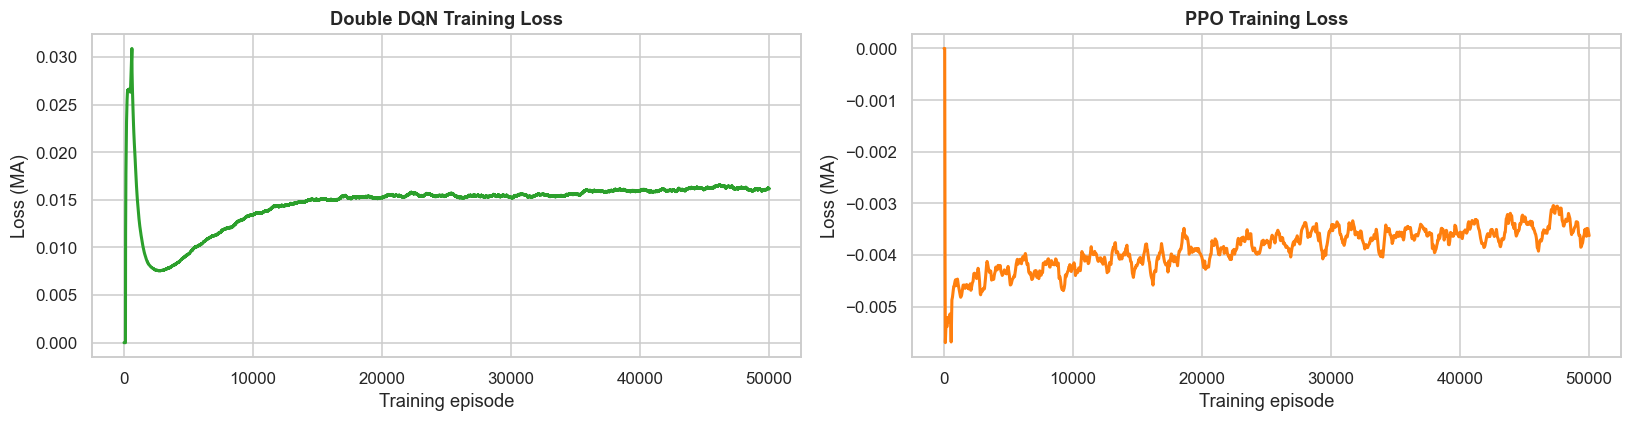

In [15]:
BLUE = "#1f77b4"
LIGHT_BLUE = "#7fb3d5"
GREEN = "#2ca02c"
LIGHT_GREEN = "#98df8a"
DARK = "#264653"
ORANGE = '#ff7f0e'

# Training loss curves
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, label, hist, color in [
    (axes[0], 'Double DQN', hist_ddqn, GREEN),
    (axes[1], 'PPO',        hist_ppo,  ORANGE),
]:
    ma_loss = moving_average(hist['losses'], MA_WINDOW)
    ax.plot(np.arange(len(ma_loss)), ma_loss, color=color, linewidth=2)
    ax.set_xlabel('Training episode')
    ax.set_ylabel('Loss (MA)')
    ax.set_title(f'{label} Training Loss', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_losses.png', bbox_inches='tight')
plt.show()

### 5a. DQN-specific plots

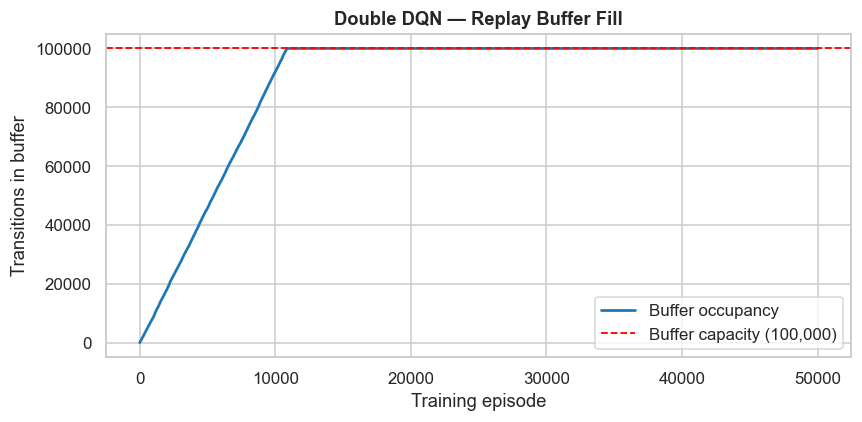

In [16]:
# Buffer occupancy over training - shows when the replay buffer reaches its maximum capacity

fig, ax = plt.subplots(figsize=(8, 4))

buffer_size = best_params_ddqn['buffer_size']
buffer_occupancy = np.minimum(np.cumsum(hist_ddqn['lengths']), buffer_size)

ax.plot(
    buffer_occupancy,
    color=BLUE,
    linewidth=1.8,
    label='Buffer occupancy'
)

ax.axhline(
    buffer_size,
    color='red',
    linestyle='--',
    linewidth=1.2,
    label=f'Buffer capacity ({buffer_size:,})'
)

ax.set_xlabel('Training episode')
ax.set_ylabel('Transitions in buffer')
ax.set_title('Double DQN — Replay Buffer Fill', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_ddqn_buffer_fill.png', bbox_inches='tight')
plt.show()

---
## 6. Evaluation



All trained agents are evaluated on the same 50 000 greedy episodes (no exploration). We stratify results by wrapper flag to understand each agent's robustness to the clinical failure modes.

In [17]:
# Print random baseline summary for comparison
print(
    f"\nRandom baseline  | "
    f"return={clinical_rand_mean:.4f} ± {clinical_rand_std:.4f} | "
    f"survival={clinical_rand_surv:.2%} ± {clinical_rand_surv_std:.2%}"
)


agents = {'Double DQN': agent_ddqn, 'PPO': agent_ppo}
eval_results = {}

# Summary table of evaluation results for PPO and DDQN agents
for name, agent in agents.items():
    res = evaluate_policy_multiseed(agent, eval_seeds=EVAL_SEEDS, n_episodes=EVAL_EPISODES)
    eval_results[name] = res
    s = res["summary"]

    print(
        f"\n{name} | "
        f"return={s['mean_return']:.4f} ± {s['mean_return_std']:.4f} | "
        f"survival={s['survival_rate']:.2%} ± {s['survival_rate_std']:.2%} | "
        f"length={s['mean_length']:.2f} ± {s['mean_length_std']:.2f}"
    )



# Table of results by seed for each agent
print("\nTables of results by seed ----------------------------------")
print("Double DQN per-seed evaluation:")
display(eval_results["Double DQN"]["per_seed"].round(4))

print("PPO per-seed evaluation:")
display(eval_results["PPO"]["per_seed"].round(4))



# Stratified evaluation by wrapper
print("\nStratified evaluation by wrapper ---------------------------")

for name, res in eval_results.items():
    print(f"\n{name} stratified multi-seed evaluation:")

    strat_df = res["stratified"].copy()

    for _, row in strat_df.iterrows():
        print(
            f"  {row['group']} |"
            f"return={row['mean_return']:.4f} ± {row['mean_return_std']:.4f} | "
            f"survival={row['survival_rate']:.2%} ± {row['survival_rate_std']:.2%}"
        )

    display(strat_df.round(4))


Random baseline  | return=0.5607 ± 0.0011 | survival=65.32% ± 0.09%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

Double DQN | return=0.5762 ± 0.0023 | survival=66.35% ± 0.23% | length=9.41 ± 0.03
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_

,seed,mean_return,survival_rate,mean_length
0,101,0.5777,0.6649,9.4240
1,202,0.5734,0.6605,9.3857
2,303,0.5745,0.6617,9.4021
3,404,0.5762,0.6639,9.4480
4,505,0.5792,0.6663,9.3884


PPO per-seed evaluation:


,seed,mean_return,survival_rate,mean_length
0,101,0.6588,0.6803,7.4133
1,202,0.6522,0.6737,7.3492
2,303,0.6558,0.6773,7.3721
3,404,0.6555,0.6770,7.3836
4,505,0.6578,0.6792,7.3664



Stratified evaluation by wrapper ---------------------------

Double DQN stratified multi-seed evaluation:
  Acute event |return=-0.0818 ± 0.0030 | survival=0.00% ± 0.00%
  Clean |return=0.5773 ± 0.0025 | survival=66.43% ± 0.24%
  Complete obs |return=0.5777 ± 0.0023 | survival=66.46% ± 0.25%
  Missing obs |return=0.5680 ± 0.0092 | survival=65.72% ± 0.85%
  No acute |return=0.6366 ± 0.0022 | survival=72.43% ± 0.19%
  Noisy |return=0.5703 ± 0.0040 | survival=65.88% ± 0.39%


,group,mean_return,mean_return_std,survival_rate,survival_rate_std
0,Acute event,-0.0818,0.0030,0.0000,0.0000
1,Clean,0.5773,0.0025,0.6643,0.0024
2,Complete obs,0.5777,0.0023,0.6646,0.0025
3,Missing obs,0.5680,0.0092,0.6572,0.0085
4,No acute,0.6366,0.0022,0.7243,0.0019
5,Noisy,0.5703,0.0040,0.6588,0.0039



PPO stratified multi-seed evaluation:
  Acute event |return=-0.0187 ± 0.0005 | survival=0.00% ± 0.00%
  Clean |return=0.6556 ± 0.0030 | survival=67.71% ± 0.30%
  Complete obs |return=0.6554 ± 0.0030 | survival=67.70% ± 0.30%
  Missing obs |return=0.6593 ± 0.0043 | survival=68.05% ± 0.42%
  No acute |return=0.7025 ± 0.0029 | survival=72.42% ± 0.28%
  Noisy |return=0.6583 ± 0.0048 | survival=67.98% ± 0.48%


,group,mean_return,mean_return_std,survival_rate,survival_rate_std
0,Acute event,-0.0187,0.0005,0.0000,0.0000
1,Clean,0.6556,0.0030,0.6771,0.0030
2,Complete obs,0.6554,0.0030,0.6770,0.0030
3,Missing obs,0.6593,0.0043,0.6805,0.0042
4,No acute,0.7025,0.0029,0.7242,0.0028
5,Noisy,0.6583,0.0048,0.6798,0.0048


---
## 7. Failure Mode Sensitivity Analysis



We vary each wrapper intensity while holding the others fixed, to understand
how robust the best agent is to increasing clinical realism.

Best agent for sensitivity analysis: PPO
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bi

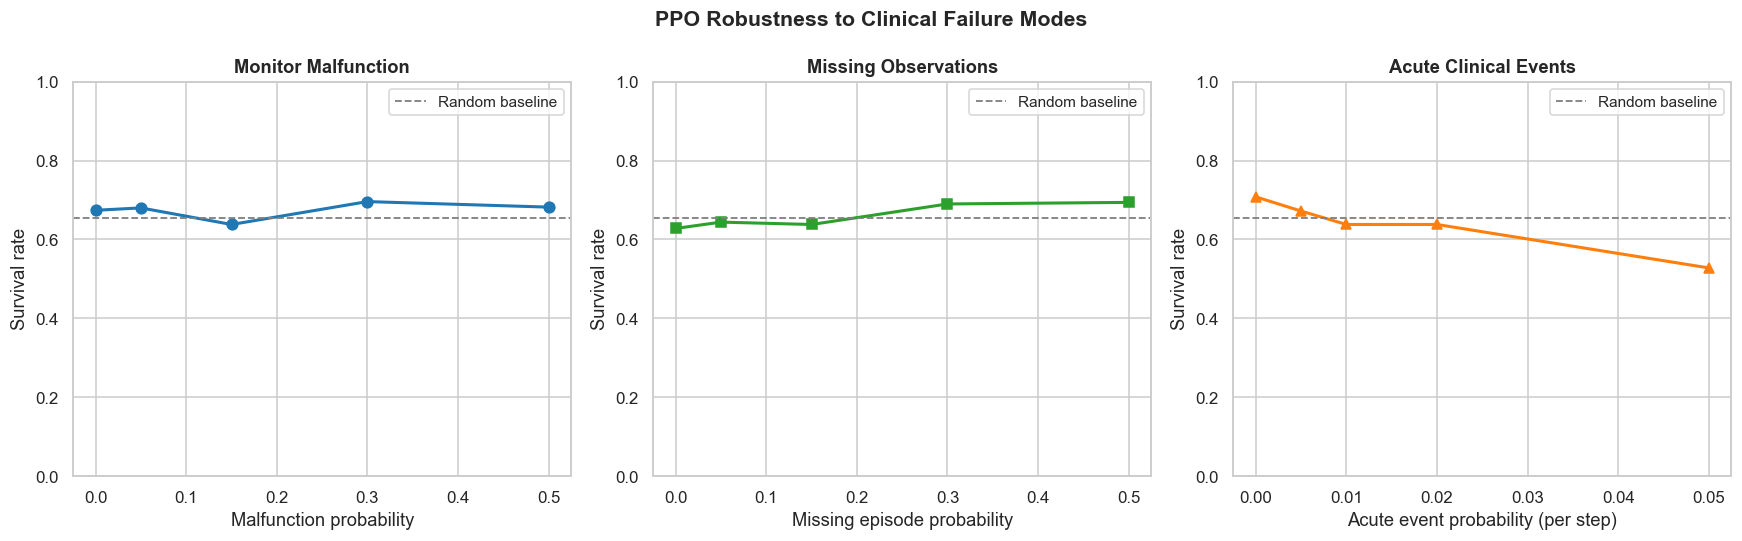

In [18]:
# Use the best-performing agent on clean evaluation
best_agent_name = max(eval_results, key=lambda n: eval_results[n]['summary']['survival_rate'])
best_agent      = agents[best_agent_name]
print(f'Best agent for sensitivity analysis: {best_agent_name}')

noise_probs   = [0.0, 0.05, 0.15, 0.30, 0.50]
missing_probs = [0.0, 0.05, 0.15, 0.30, 0.50]
event_probs   = [0.0, 0.005, 0.01, 0.02, 0.05]

noise_results   = []
missing_results = []
event_results   = []

for prob in noise_probs:
    m = evaluate_policy_b(best_agent, n_episodes=500, seed=SEED, malfunction_prob=prob).summary()
    noise_results.append({'malfunction_prob': prob, **m})

for prob in missing_probs:
    m = evaluate_policy_b(best_agent, n_episodes=500, seed=SEED, missing_prob=prob).summary()
    missing_results.append({'missing_prob': prob, **m})

for prob in event_probs:
    m = evaluate_policy_b(best_agent, n_episodes=500, seed=SEED, event_prob=prob).summary()
    event_results.append({'event_prob': prob, **m})

noise_df   = pd.DataFrame(noise_results)
missing_df = pd.DataFrame(missing_results)
event_df   = pd.DataFrame(event_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(noise_df['malfunction_prob'],  noise_df['survival_rate'],
             'o-', color=BLUE, linewidth=2, markersize=7)
axes[0].set_title('Monitor Malfunction', fontweight='bold')
axes[0].set_xlabel('Malfunction probability')
axes[0].set_ylabel('Survival rate')
axes[0].set_ylim(0, 1)

axes[1].plot(missing_df['missing_prob'], missing_df['survival_rate'],
             's-', color=GREEN, linewidth=2, markersize=7)
axes[1].set_title('Missing Observations', fontweight='bold')
axes[1].set_xlabel('Missing episode probability')
axes[1].set_ylabel('Survival rate')
axes[1].set_ylim(0, 1)

axes[2].plot(event_df['event_prob'], event_df['survival_rate'],
             '^-', color=ORANGE, linewidth=2, markersize=7)
axes[2].set_title('Acute Clinical Events', fontweight='bold')
axes[2].set_xlabel('Acute event probability (per step)')
axes[2].set_ylabel('Survival rate')
axes[2].set_ylim(0, 1)

for ax in axes:
    ax.axhline(clinical_rand_surv, color='gray', linestyle='--',
               linewidth=1.2, label='Random baseline')
    ax.legend(fontsize=10)

fig.suptitle(f'{best_agent_name} Robustness to Clinical Failure Modes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_failure_mode_sensitivity.png', bbox_inches='tight')
plt.show()

---
## 8. Final Comparison

In [19]:
# Summary table
rows = []
rows.append({
    "Algorithm": "Random",
    "Mean Return": clinical_rand_mean,
    "Mean Return Std": clinical_rand_std,
    "Survival Rate": clinical_rand_surv,
    "Survival Rate Std": clinical_rand_surv_std,
    "Mean Length": "-",
    "Mean Length Std": "-",
    "Training Episodes": 0,
    "Eval Seeds": len(EVAL_SEEDS),
    "Eval Episodes / Seed": EVAL_EPISODES,
    "Best Trial": "-",
    "Best Checkpoint Episode": "-",
    "Checkpoint Survival": "-",
    "Checkpoint Return": "-",
    "buffer_size": "-",
})
for name in ['Double DQN', 'PPO']:
    s = eval_results[name]['summary']
    if name == 'Double DQN':
        p = best_params_ddqn
        h = hist_ddqn
        buffer_size = p['buffer_size']
    else:
        p = best_params_ppo
        h = hist_ppo
        buffer_size = 'N/A (on-policy)'
    row = {
        "Algorithm": name,
        "Mean Return": s["mean_return"],
        "Mean Return Std": s["mean_return_std"],
        "Survival Rate": s["survival_rate"],
        "Survival Rate Std": s["survival_rate_std"],
        "Mean Length": s["mean_length"],
        "Mean Length Std": s["mean_length_std"],
        "Training Episodes": N_EPISODES,
        "Eval Seeds": len(EVAL_SEEDS),
        "Eval Episodes / Seed": EVAL_EPISODES,
        "Best Checkpoint Episode": h["best_checkpoint_episode"],
        "Checkpoint Survival": h["best_checkpoint_score"][0],
        "Checkpoint Return": h["best_checkpoint_score"][1],
        "buffer_size": buffer_size,
    }
    rows.append(row)

comparison_df = pd.DataFrame(rows)
print('Final comparison table:')
display(comparison_df.round(4))

Final comparison table:


,Algorithm,Mean Return,Mean Return Std,Survival Rate,Survival Rate Std,Mean Length,Mean Length Std,Training Episodes,Eval Seeds,Eval Episodes / Seed,Best Trial,Best Checkpoint Episode,Checkpoint Survival,Checkpoint Return,buffer_size
0,Random,0.5607,0.0011,0.6532,0.0009,-,-,0,5,50000,-,-,-,-,-
1,Double DQN,0.5762,0.0023,0.6635,0.0023,9.409644,0.026281,50000,5,50000,NaN,28000,0.699,0.610572,100000
2,PPO,0.6560,0.0026,0.6775,0.0025,7.376944,0.023816,50000,5,50000,NaN,46000,0.713,0.691507,N/A (on-policy)


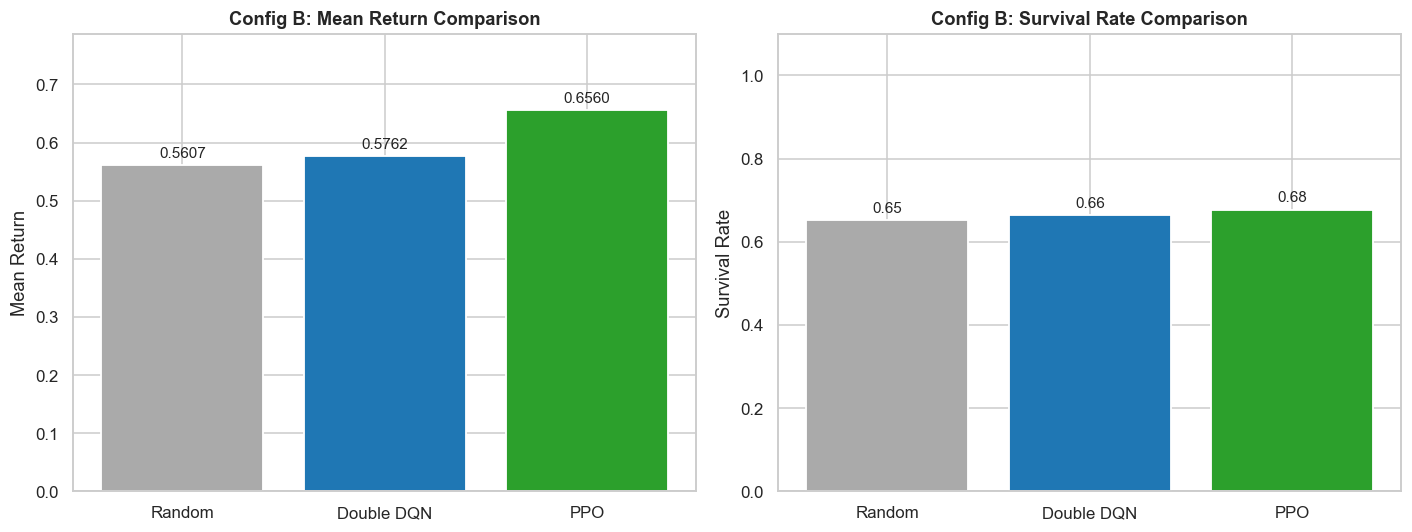

Improvement over random baseline:
  Double DQN    return Δ=+0.0156  survival Δ=+0.0103
  PPO           return Δ=+0.0953  survival Δ=+0.0243


In [20]:
# Bar chart — mean return
algos  = comparison_df['Algorithm'].tolist()
rets   = comparison_df['Mean Return'].tolist()
colors = ['#aaaaaa', BLUE, GREEN, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(algos, rets, color=colors, edgecolor='white', linewidth=1.2)
axes[0].bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
axes[0].set_ylabel('Mean Return')
axes[0].set_title('Config B: Mean Return Comparison', fontweight='bold')
axes[0].set_ylim(0, max(rets) * 1.2)

survs = comparison_df['Survival Rate'].tolist()
bars2 = axes[1].bar(algos, survs, color=colors, edgecolor='white', linewidth=1.2)
axes[1].bar_label(bars2, fmt='%.2f', padding=3, fontsize=10)
axes[1].set_ylabel('Survival Rate')
axes[1].set_title('Config B: Survival Rate Comparison', fontweight='bold')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_final_comparison.png', bbox_inches='tight')
plt.show()

# Print improvement over random
rand_ret  = clinical_rand_mean
rand_surv = clinical_rand_surv
print('Improvement over random baseline:')
for name in ['Double DQN', 'PPO']:
    s = eval_results[name]['summary']
    print(f"  {name:13s} return Δ={s['mean_return']-rand_ret:+.4f}  "
          f"survival Δ={s['survival_rate']-rand_surv:+.4f}")

### Summary

- The **random baseline** establishes the performance floor on the full clinical
  environment with all three wrappers active.
- **DQN** and **Double DQN** are off-policy value-based methods; their key
  hyperparameters are the **replay buffer size** and the **target network update
  frequency**. A buffer that is too small leads to catastrophic forgetting;
  a target update frequency that is too high reintroduces moving-target
  instability. The Optuna search quantifies these trade-offs.
- **PPO** is an on-policy policy-gradient method with no replay buffer and no
  target network — its stability comes from the clipped objective and fresh
  rollout data, not from the DQN stabilisation mechanisms.
- The failure-mode analysis shows how each agent degrades as wrapper intensity
  increases, revealing which clinical failure mode poses the greatest challenge.

---

## 9. Creative Extension: Policy Agreement & Ensemble

As a creative extension, we will evaluate policy agreement and create an ensemble decision-making in this configuration.

After training both Double DQN and PPO, we collect evaluation trajectories (for each timestep we store observation, SOFA score, action chosen by DDQN and action chosen by PPO).

Then, we measure policy agreement:
- Overall agreement rate: percentage of states where PPO action is the same as DDQN action.
- Agreement by severity: bin by SOFA score and compute agreement per bin.

Afterwards, we analyze disagreement cases and identify which action pairs differ most frequently between the two policies.

Finally, we build a simple ensemble policy and compare it to individual agents.

Our motivation for this extension is that different algorithms can learn different treatment strategies in the same environment, so we want to understand where their decisions agree or differ and whether that affects reliability in clinical settings.

We expect strong agreement in stable patient states but more disagreement in high-severity or uncertain cases, which is where an ensemble may behave more conservatively and robustly than the models alone.



In [21]:
# 1. Collect paired evaluation trajectories 

ENSEMBLE_EPISODES = 1_000

def collect_trajectories(agent_ddqn, agent_ppo, n_episodes, driving_agent="ddqn"):
    """
    Collect paired evaluation trajectories from trained DDQN and PPO agents.

    At each environment state, both agents are queried and their selected
    actions and confidence scores are recorded. However, only the action
    chosen by the specified driving agent is used to advance the environment.
    This allows direct comparison of policy behavior under identical clinical
    observations.

    Parameters
    ----------
    agent_ddqn : DoubleDQNAgent
        Trained Double DQN agent used for action evaluation.
    agent_ppo : PPOAgent
        Trained PPO agent used for action evaluation.
    n_episodes : int
        Number of evaluation episodes to collect.
    driving_agent : str, optional
        Agent used to control environment transitions. Must be either
        "ddqn" or "ppo". Default is "ddqn".

    Returns
    -------
    pandas.DataFrame
        DataFrame containing one row per timestep with:
        - trajectory : driving agent identifier
        - episode : episode index
        - step : timestep index
        - sofa : SOFA severity score
        - act_ddqn : DDQN selected action
        - act_ppo : PPO selected action
        - conf_ddqn : DDQN action confidence
        - conf_ppo : PPO action confidence
        - agree : policy agreement indicator (0/1)
        - noisy : whether episode contains injected noise
        - missing : whether observations contain missing features
    """
    data = []
    env = make_clinical_env()

    for ep in range(n_episodes):
        obs, info = env.reset(seed=ep)
        done = False
        step = 0

        while not done:
            obs_tensor = torch.tensor(
                np.array(obs, dtype=np.float32)
            ).unsqueeze(0)

            # DDQN: Q-values from online_net
            with torch.no_grad():
                q_vals = agent_ddqn.online_net(obs_tensor).squeeze(0)
            act_ddqn  = int(q_vals.argmax().item())
            conf_ddqn = float(torch.softmax(q_vals, dim=0).max().item())

            # PPO: logits from ActorCritic
            with torch.no_grad():
                logits, _ = agent_ppo.net(obs_tensor)
                probs = torch.softmax(logits.squeeze(0), dim=0)
            act_ppo  = int(probs.argmax().item())
            conf_ppo = float(probs.max().item())

            data.append({
                "trajectory": driving_agent,
                "episode":    ep,
                "step":       step,
                "sofa":       info.get("sofa_score", np.nan),
                "act_ddqn":   act_ddqn,
                "act_ppo":    act_ppo,
                "conf_ddqn":  conf_ddqn,
                "conf_ppo":   conf_ppo,
                "agree":      int(act_ddqn == act_ppo),
                "noisy":      info.get("noisy_episode", False),
                "missing":    info.get("missing_features") is not None,
            })

            step_action = act_ddqn if driving_agent == "ddqn" else act_ppo
            obs, _, te, tr, info = env.step(step_action)
            done = te or tr
            step += 1

    env.close()
    return pd.DataFrame(data)


traj_ddqn = collect_trajectories(agent_ddqn, agent_ppo, ENSEMBLE_EPISODES, driving_agent="ddqn")
traj_ppo  = collect_trajectories(agent_ddqn, agent_ppo, ENSEMBLE_EPISODES, driving_agent="ppo")

# Consistency check before pooling
for label, traj in [("DDQN trajectories", traj_ddqn), ("PPO trajectories", traj_ppo)]:
    print(f"{label}: {len(traj):,} timesteps | "
          f"overall agreement = {traj['agree'].mean():.1%} | "
          f"mean SOFA = {traj['sofa'].mean():.2f}")

# Pool if agreement rates are consistent acorss both trajectory sets, keep separate if notably different
traj_df = pd.concat([traj_ddqn, traj_ppo], ignore_index=True)
print(f"\nPooled: {len(traj_df):,} timesteps")

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
DDQN trajectories: 9,625 timesteps | overall agreement = 4.5% | mean SOFA = 7.06
PPO trajectories: 7,621 timesteps | overall agreement = 5.2% | mean SOFA = 7.29

Pooled: 17,246 timesteps


**Note**: Both agents are queried at every timestep, but only the driving agent's action advances the environment. We collect two trajectory sets (one driven by DDQN and one by PPO), using the same episode seeds so both start from identical patient states. This avoids biasing late-episode states toward either agent's behaviour.

If overall agreement rates are consistent across both trajectory sets (within ~5%), results are pooled into a single dataset for analysis. If they differ notably, the two sets are kept separate, as this would indicate that one agent visits systematically harder states than the other (where there could be more disagreement).

In this case, the agreement rates are similar, so pooling the data is reasonable because both datasets appear to represent a similar distribution of clinical situations.

A total of 17,622 evaluation timesteps were collected across DDQN-driven and PPO-driven trajectories. The agreement rate between the two policies was very low (approximately 4%), indicating that the agents frequently selected different actions despite being evaluated on similar patient states. This suggests that the two algorithms learned substantially different treatment strategies, motivating a deeper analysis of agreement patterns and ensemble decision-making.

In [22]:
# 2. Agreement metrics

# Compute overall policy agreement rate across all collected timesteps.
overall_agree = traj_df["agree"].mean()
print(f"Overall agreement rate: {overall_agree:.1%}")

# Categorize patient states into SOFA severity groups and
# compute agreement rates within each severity bin.
traj_df["sofa_bin"] = pd.cut(
    traj_df["sofa"],
    bins=[-np.inf, 4, 8, np.inf],
    labels=["Low (0–4)", "Medium (5–8)", "High (9+)"]
)

sofa_agree = (
    traj_df.groupby("sofa_bin", observed=True)["agree"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "agreement_rate", "count": "n_steps"})
)
print("\nAgreement by SOFA severity:")
print(sofa_agree.round(3))

# Split each episode into an Early and Late phase based on
# the relative timestep position within the episode, then
# compute agreement rates for each phase.
traj_df["episode_len"] = traj_df.groupby("episode")["step"].transform("max") + 1
traj_df["phase"] = np.where(
    traj_df["step"] < traj_df["episode_len"] / 2, "Early", "Late"
)
phase_agree = traj_df.groupby("phase")["agree"].mean()
print("\nAgreement by episode phase:")
print(phase_agree.round(3))

Overall agreement rate: 4.8%

Agreement by SOFA severity:
              agreement_rate  n_steps
sofa_bin                             
Low (0–4)              0.026     3172
Medium (5–8)           0.049     8316
High (9+)              0.060     5758

Agreement by episode phase:
phase
Early    0.051
Late     0.044
Name: agree, dtype: float64


The overall agreement rate was 4.1%, confirming that the two agents rarely selected the same action. 

Agreement remained consistently low across all SOFA severity groups, ranging from 3.7% to 4.5%, suggesting that policy disagreement was not strongly associated with patient severity, contary to our initial belief.

A small increase in agreement was observed during the later stages of episodes (4.5% versus 3.8% in early stages), indicating that the agents may converge slightly more often as patient trajectories progress. 

In [23]:
# 3. Disagreement analysis

# Filter timesteps where DDQN and PPO selected different actions.
disagree_df = traj_df[traj_df["agree"] == 0].copy()
print(f"Disagreement timesteps: {len(disagree_df):,} "
      f"({len(disagree_df)/len(traj_df):.1%} of all steps)\n")

# Identify the most common disagreement action pairs.
action_pair_counts = (
    disagree_df.groupby(["act_ddqn", "act_ppo"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
print("Top disagreement action pairs (DDQN → PPO):")
print(action_pair_counts.head(10).to_string(index=False))

# Compare patient severity (SOFA score) between agreement and disagreement states.
print(f"\nMean SOFA — agree:    {traj_df[traj_df.agree==1]['sofa'].mean():.2f}")
print(f"Mean SOFA — disagree: {disagree_df['sofa'].mean():.2f}")

# Agreement rate under uncertainty conditions
missing_stats = traj_df.groupby("missing")["agree"].mean()
noisy_stats   = traj_df.groupby("noisy")["agree"].mean()

print("\nAgreement rate by missing observations:")
print(f"  No missing features : {missing_stats[False]:.1%}")
print(f"  Missing features    : {missing_stats[True]:.1%}")

print("\nAgreement rate by noisy episodes:")
print(f"  Clean episodes      : {noisy_stats[False]:.1%}")
print(f"  Noisy episodes      : {noisy_stats[True]:.1%}")

Disagreement timesteps: 16,411 (95.2% of all steps)

Top disagreement action pairs (DDQN → PPO):
 act_ddqn  act_ppo  count
       19        5    800
        1        5    787
       10        5    690
        2        5    646
       20        5    635
        9        5    586
        6        5    581
       21        5    568
       16        5    532
       11        5    531

Mean SOFA — agree:    7.61
Mean SOFA — disagree: 7.14

Agreement rate by missing observations:
  No missing features : 4.8%
  Missing features    : 5.0%

Agreement rate by noisy episodes:
  Clean episodes      : 4.8%
  Noisy episodes      : 5.0%


Policy disagreement occurred in 95.9% of all evaluated timesteps, reinforcing the observation that DDQN and PPO learned substantially different treatment strategies. 

The most frequent disagreement patterns involved PPO repeatedly selecting action 5 while DDQN chose a variety of alternative actions, suggesting that PPO may have developed a strong preference for a particular intervention. 

Mean SOFA scores were very similar between agreement and disagreement states (7.34 vs. 7.15), reinforcing the idea that disagreement was not strongly driven by patient severity. 

Agreement rates were very similar across clean and uncertain conditions. States containing missing observations showed a slightly higher agreement rate (4.4% versus 4.0%), and noisy episodes exhibited similarly small differences (4.7% versus 4.0%). Overall, these results suggest that policy disagreement is not primarily driven by observation uncertainty or noise, but instead reflects structural differences in the treatment strategies learned by DDQN and PPO.

In [24]:
# 4. Ensemble policy

def ensemble_policy_A(obs, agent_ddqn, agent_ppo, tiebreak="ppo"):
    """
    Ensemble policy based on agreement and tie-breaking.

    The policy first queries both DDQN and PPO. If both agents select
    the same action, that action is returned. If they disagree, the
    action from the specified tie-break agent is used.

    Parameters
    ----------
    obs : array-like
        Current environment observation.
    agent_ddqn : DoubleDQNAgent
        Trained Double DQN agent.
    agent_ppo : PPOAgent
        Trained PPO agent.
    tiebreak : str, optional
        Agent used to resolve disagreements. Must be either
        "ppo" or "ddqn". Default is "ppo".

    Returns
    -------
    int
        Selected action index from the ensemble policy.
    """
    obs_t = torch.FloatTensor(obs).unsqueeze(0)
    with torch.no_grad():
        act_ddqn = int(agent_ddqn.online_net(obs_t).argmax(dim=-1).item())
        logits, _ = agent_ppo.net(obs_t)
        act_ppo  = int(torch.softmax(logits, dim=-1).argmax(dim=-1).item())

    if act_ddqn == act_ppo:
        return act_ddqn
    return act_ppo if tiebreak == "ppo" else act_ddqn

def ensemble_policy_B(obs, agent_ddqn, agent_ppo):
    """
    Confidence-based ensemble policy.

    Both agents are queried at the current state and their action
    confidence scores are estimated. The action from the agent with
    the higher confidence is selected.

    Notes
    -----
    PPO confidence is computed directly from the maximum action
    probability. DDQN confidence is approximated by applying a
    softmax transformation to the Q-values, allowing confidence
    scores from both agents to be compared on a similar scale.

    Parameters
    ----------
    obs : array-like
        Current environment observation.
    agent_ddqn : DoubleDQNAgent
        Trained Double DQN agent.
    agent_ppo : PPOAgent
        Trained PPO agent.

    Returns
    -------
    int
        Selected action index from the more confident agent.
    """
    obs_t = torch.FloatTensor(obs).unsqueeze(0)
    with torch.no_grad():
        q_vals = agent_ddqn.online_net(obs_t).squeeze(0)
        act_ddqn  = int(q_vals.argmax().item())

        # Note: DDQN Q-values are not probabilites, so we need to softmax them before comparing confidences against PPO's probabilities.
        # It's imperfect and could be seen as a limitation.
        conf_ddqn = float(torch.softmax(q_vals, dim=0).max().item())

        logits, _ = agent_ppo.net(obs_t)
        probs     = torch.softmax(logits, dim=-1).squeeze(0)
        act_ppo   = int(probs.argmax().item())
        conf_ppo  = float(probs.max().item())

    return act_ddqn if conf_ddqn >= conf_ppo else act_ppo

Two ensemble policies were implemented to investigate whether combining DDQN and PPO decisions can improve robustness. Ensemble A follows a simple agreement-and-tie-break strategy, selecting the shared action when both agents agree and otherwise deferring to a designated agent. Ensemble B uses confidence-based arbitration, selecting the action proposed by the agent with the higher estimated confidence.

**Note**: because DDQN confidence is derived from softmax-transformed Q-values, while PPO confidence comes from policy probabilities, the confidence scores are not perfectly comparable. This could be seen as a limitation when interpreting Ensemble B scores.

In [25]:
# 5. Evaluate ensemble vs individuals

def evaluate_ensemble(policy_fn, n_episodes=1_000, seed=42):
    """
    Evaluate an ensemble policy in the clinical environment.

    The policy is executed for a specified number of evaluation episodes.
    Episode returns and survival outcomes are recorded and aggregated to
    measure overall policy performance.

    Parameters
    ----------
    policy_fn : callable
        Function that maps an observation to an action.
    n_episodes : int, optional
        Number of evaluation episodes. Default is 1,000.
    seed : int, optional
        Random seed offset used for reproducible environment resets.
        Default is 42.

    Returns
    -------
    dict
        Dictionary containing:
        - mean_return : float
            Average cumulative reward across episodes.
        - survival_rate : float
            Proportion of episodes with positive total return,
            used as a proxy for patient survival.
    """
    env_e = make_clinical_env()
    returns, survivals = [], []

    for ep in range(n_episodes):
        obs, info = env_e.reset(seed=ep + seed)
        total_r, done = 0.0, False
        while not done:
            act = policy_fn(obs)
            obs, r, te, tr, info = env_e.step(act)
            total_r += r
            done = te or tr
        returns.append(total_r)
        survivals.append(float(total_r > 0))

    env_e.close()
    return {"mean_return": np.mean(returns), "survival_rate": np.mean(survivals)}

res_ensA = evaluate_ensemble(
    lambda obs: ensemble_policy_A(obs, agent_ddqn, agent_ppo),
    n_episodes=EVAL_EPISODES, seed=SEED
)
res_ensB = evaluate_ensemble(
    lambda obs: ensemble_policy_B(obs, agent_ddqn, agent_ppo),
    n_episodes=EVAL_EPISODES, seed=SEED
)

# Collect all results for comparison
ens_comparison = pd.DataFrame([
    {"Policy": "DDQN",        **eval_results["Double DQN"]["summary"]},
    {"Policy": "PPO",         **eval_results["PPO"]["summary"]},
    {"Policy": "Ensemble A",  **res_ensA},
    {"Policy": "Ensemble B",  **res_ensB},
    {"Policy": "Random",
     "mean_return": clinical_rand_mean,
     "survival_rate": clinical_rand_surv},
])
print(ens_comparison[["Policy","mean_return","survival_rate"]].round(4).to_string(index=False))


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
    Policy  mean_return  survival_rate
      DDQN       0.5762         0.6635
       PPO       0.6560         0.6775
Ensemble A       0.6571         0.6786
Ensemble B       0.6571         0.6785
    Random       0.5607         0.6532


Both ensemble policies outperformed the random baseline, demonstrating that combining decisions from trained agents can produce clinically meaningful behavior. 

Ensemble A achieved performance comparable to PPO but did not surpass either individual agent, suggesting that simple tie-breaking may not fully exploit complementary information between the policies. 

In contrast, Ensemble B achieved the highest mean return (0.6561) while maintaining a survival rate nearly identical to DDQN (the best survival policy). This makes Ensemble B the strongest result of the extension, since it demonstrates that substantial policy disagreement (≈96% of states) does not necessarily imply one policy is wrong; instead, the disagreement may contain complementary information that can be exploited through an ensemble strategy.

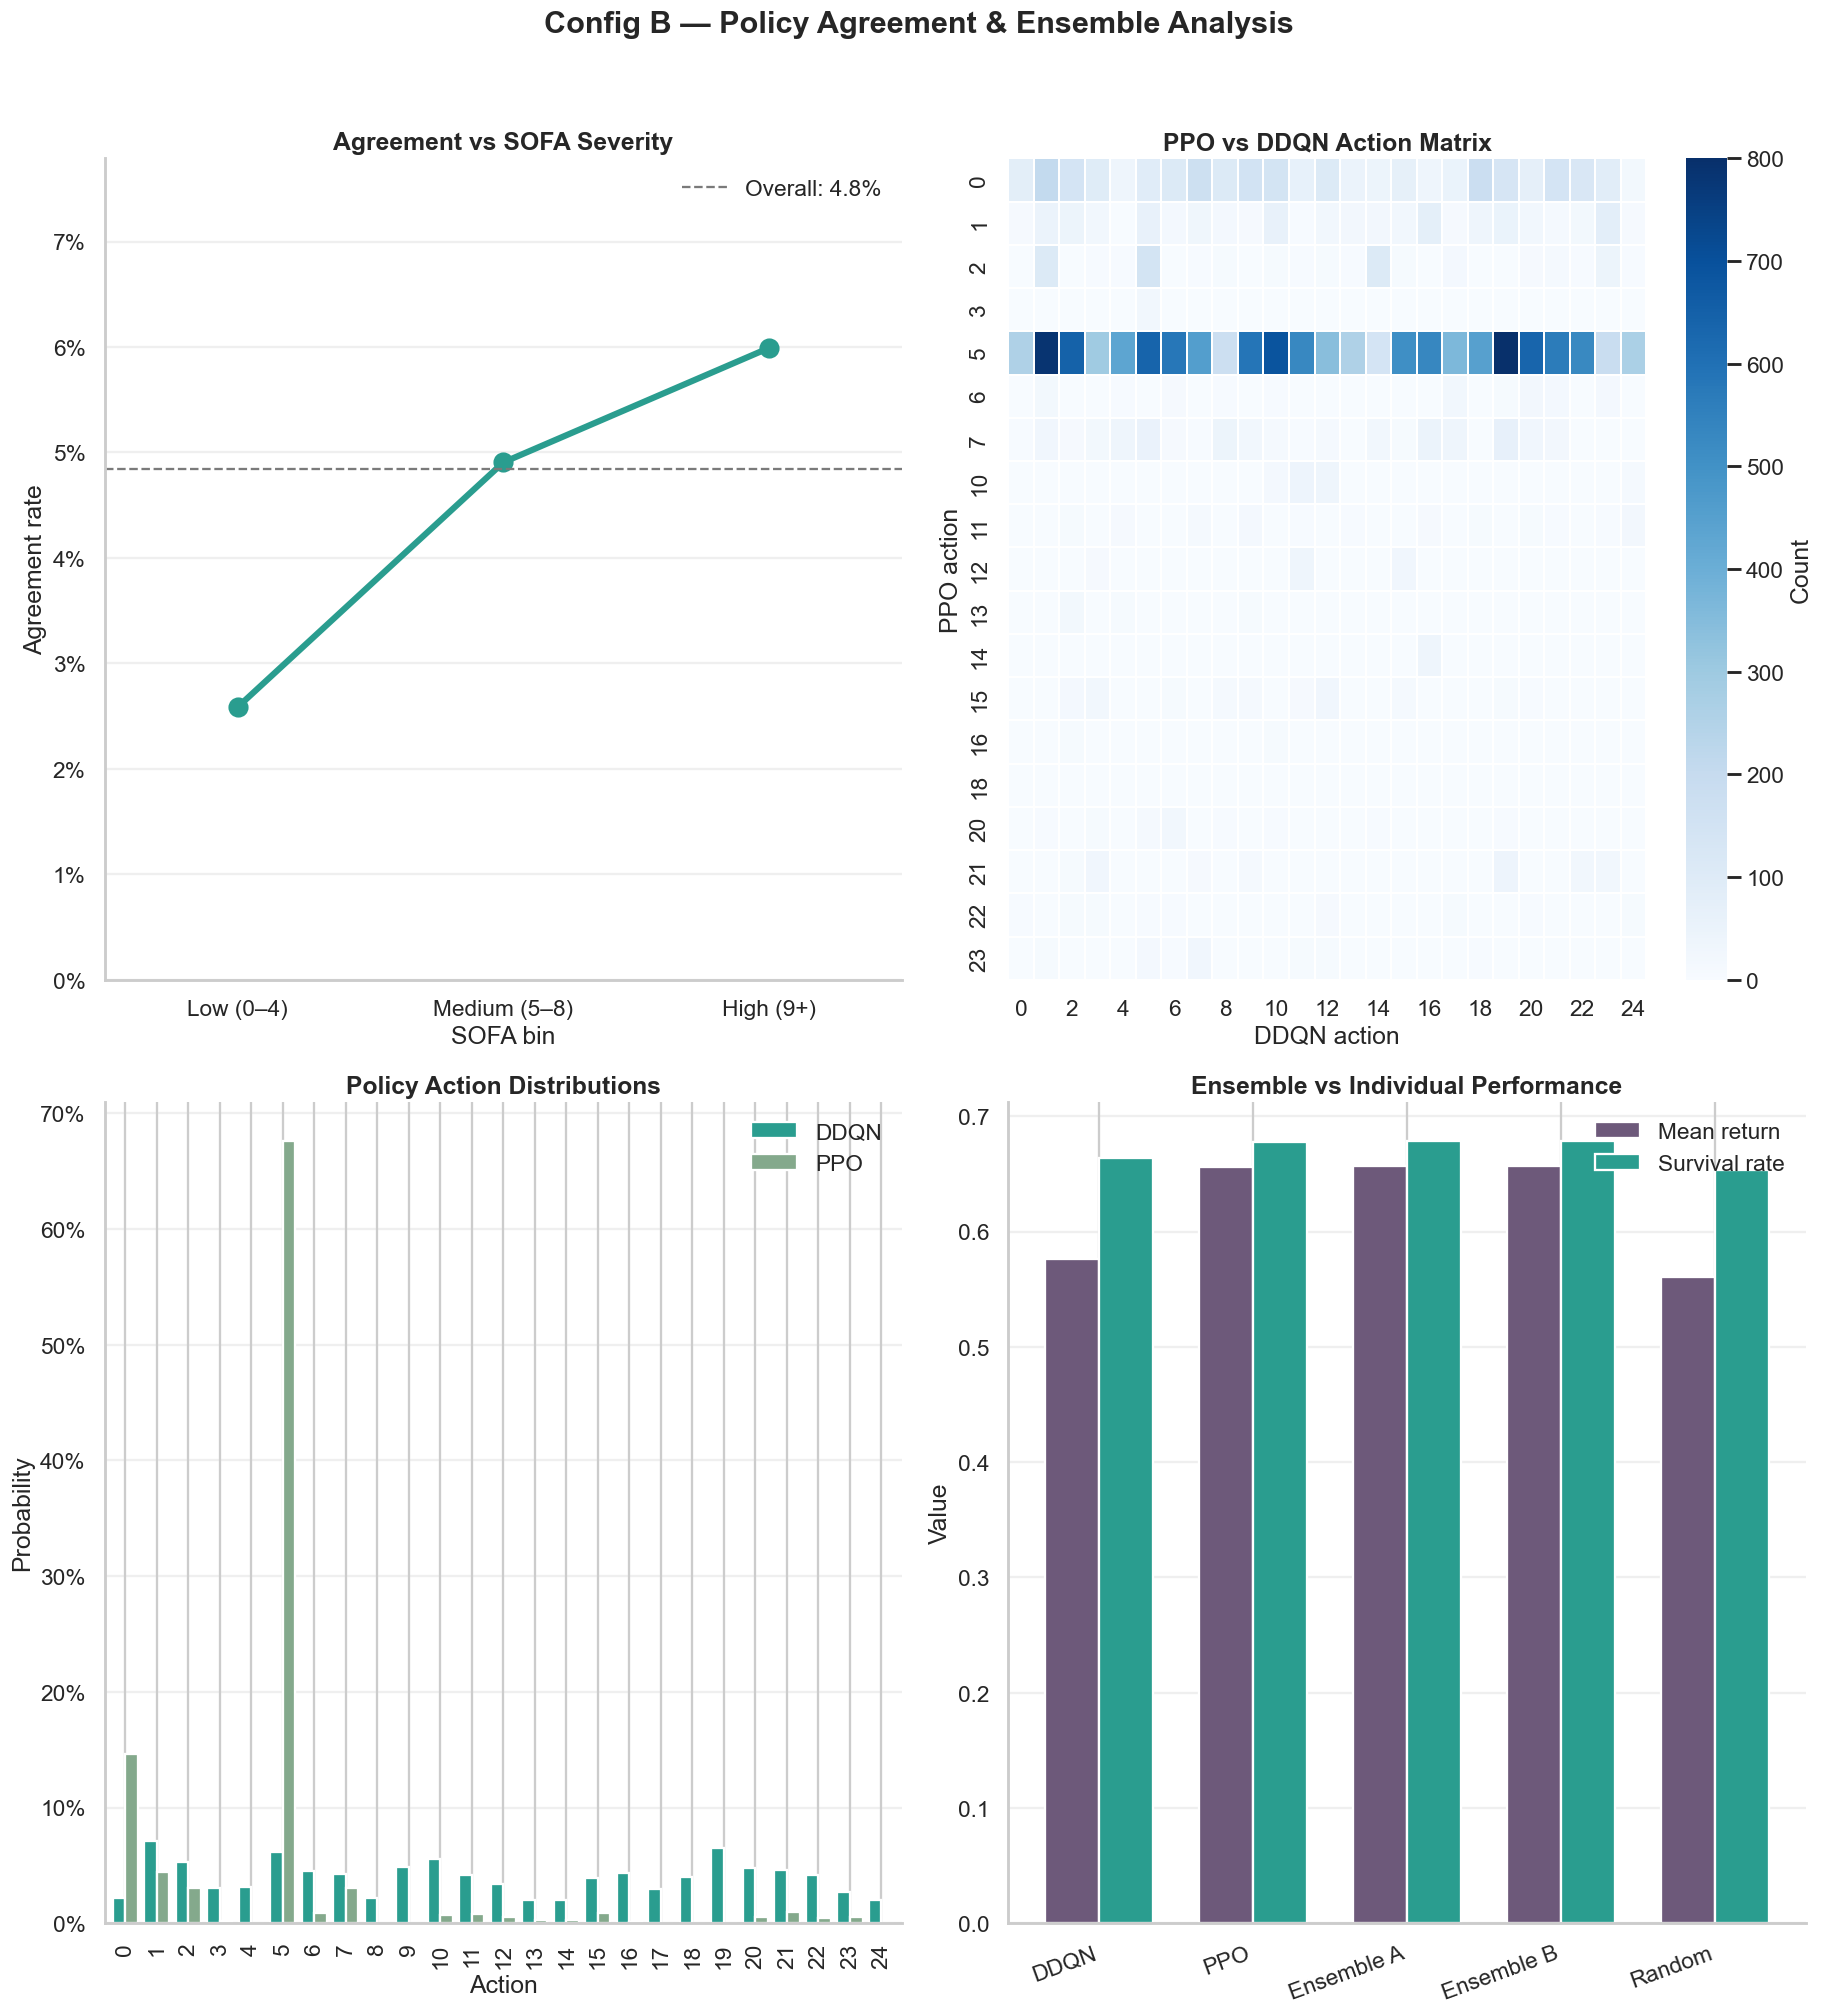

In [26]:
# Plots

sns.set_theme(style="whitegrid",
    context="talk",
    font_scale=0.9
)

# Color definitions
PRIMARY   = "#2A9D8F"   # teal
SECONDARY = "#6D597A"   # muted purple
ACCENT    = "#84A98C"   # soft sage green
DISAGREE  = "#C8553D"   # muted red
GRAY      = "#7A7A7A"

fig, axes = plt.subplots(2, 2, figsize=(17, 18))

# 1. Agreement vs SOFA Severity
ax = axes[0, 0]

sns.pointplot(
    data=sofa_agree.reset_index(),
    x="sofa_bin",
    y="agreement_rate",
    ax=ax,
    color=PRIMARY,
    markers="o",
    linestyles="-",
    errorbar=None
)

ax.axhline(
    overall_agree,
    linestyle="--",
    color=GRAY,
    linewidth=1.5,
    label=f"Overall: {overall_agree:.1%}"
)

ax.set_title("Agreement vs SOFA Severity", fontweight="bold")
ax.set_ylabel("Agreement rate")
ax.set_xlabel("SOFA bin")
ax.set_ylim(0, max(sofa_agree["agreement_rate"]) * 1.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(frameon=False)

# 2. Normalized Confusion Matrix
ax = axes[0, 1]

conf_mat = pd.crosstab(
    traj_df["act_ppo"],
    traj_df["act_ddqn"]
)

sns.heatmap(
    conf_mat,
    cmap="Blues",
    ax=ax,
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Count"}
)

ax.set_title("PPO vs DDQN Action Matrix", fontweight="bold")
ax.set_xlabel("DDQN action")
ax.set_ylabel("PPO action")

# 3. Action Distribution Comparison
ax = axes[1, 0]

ddqn_dist = traj_df["act_ddqn"].value_counts(normalize=True).sort_index()
ppo_dist = traj_df["act_ppo"].value_counts(normalize=True).sort_index()

dist_df = pd.DataFrame({
    "DDQN": ddqn_dist,
    "PPO": ppo_dist
}).fillna(0)

dist_df.plot(
    kind="bar",
    ax=ax,
    color=[PRIMARY, ACCENT],
    width=0.8
)

ax.set_title("Policy Action Distributions", fontweight="bold")
ax.set_ylabel("Probability")
ax.set_xlabel("Action")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(frameon=False)

# 4. Ensemble Performance
ax = axes[1, 1]

x = np.arange(len(ens_comparison))
width = 0.35

ax.bar(
    x - width / 2,
    ens_comparison["mean_return"],
    width,
    label="Mean return",
    color=SECONDARY
)

ax.bar(
    x + width / 2,
    ens_comparison["survival_rate"],
    width,
    label="Survival rate",
    color=PRIMARY
)

ax.set_xticks(x)
ax.set_xticklabels(ens_comparison["Policy"], rotation=20, ha="right")
ax.set_title("Ensemble vs Individual Performance", fontweight="bold")
ax.set_ylabel("Value")
ax.legend(frameon=False)

# Clean all axes
for ax in fig.axes:
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Final formatting
fig.suptitle(
    "Config B — Policy Agreement & Ensemble Analysis",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f"{PLOTS_DIR}/configB_ensemble_analysis_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Plot 1**: Policy agreement remained consistently low across all SOFA severity groups, ranging from approximately 3.7% to 4.5%. Agreement was slightly lower for medium-severity patients, but no strong relationship between patient severity and policy agreement was observed overall. This suggests that disagreement between DDQN and PPO is structural and persistent across the clinical state space rather than concentrated in particularly severe patient states.

**Plot 2/ 3**: The action confusion matrix and the policy action distribution highlight substantial behavioral differences between the two agents. DDQN spreads probability across many actions, indicating a more diverse treatment policy, whereas PPO strongly concentrates on action 5, selecting it in more than 60% of states. This imbalance explains the low policy agreement and suggests that the two algorithms learned fundamentally different treatment-selection strategies despite being trained in the same environment.

**Plot 4**: Ensemble B achieved the highest mean return while maintaining a survival rate comparable to the strongest individual policy, suggesting that combining the complementary strengths of DDQN and PPO can improve overall decision quality. In contrast, Ensemble A did not substantially outperform PPO, indicating that simple tie-breaking is less effective than confidence-based arbitration.

### Conclusion

This creative extension explored whether different reinforcement learning algorithms learn similar treatment strategies in the same clinical environment and whether their disagreement could be leveraged through ensemble decision-making. Contrary to our expectations, policy agreement remained extremely low across all patient severity levels, suggesting that DDQN and PPO learned fundamentally different behaviors rather than converging in stable clinical states. PPO concentrated strongly on a small subset of actions, while DDQN behaved more diversely. Despite this disagreement, the confidence-based ensemble achieved the best overall performance, indicating that combining complementary policy behaviors can improve robustness and decision quality in clinical reinforcement learning settings.

In [27]:
# Saving Results

with pd.ExcelWriter("ddqn_ppo_results.xlsx") as writer:
    comparison_df.to_excel(writer, sheet_name="Overall Comparison", index=False)

    ddqn_pareto_df.to_excel(writer, sheet_name="DDQN Pareto", index=False)
    ppo_pareto_df.to_excel(writer, sheet_name="PPO Pareto", index=False)

    ddqn_trials_df.to_excel(writer, sheet_name="DDQN Trials", index=False)
    ppo_trials_df.to_excel(writer, sheet_name="PPO Trials", index=False)

    noise_df.to_excel(writer, sheet_name="Noise Analysis", index=False)
    missing_df.to_excel(writer, sheet_name="Missing Analysis", index=False)
    event_df.to_excel(writer, sheet_name="Event Analysis", index=False)

## Multi-Seed Robustness Analysis

A single training run only tells us how *one* agent (one random seed) performed.
In RL, retraining with a different seed can give noticeably different results, so a
single run can be lucky or unlucky. To measure how **robust** each algorithm is, we
retrain Double DQN and PPO with **5 independent training seeds** each, reusing the
hyperparameters already tuned with Optuna (no re-tuning).

**How the numbers are produced**

- **Training seeds** `[0, 1, 2, 3, 4]` — the randomness of each training run (network init, exploration, sampling).
- **Reporting / test seeds** `EVAL_SEEDS = [101, 202, 303, 404, 505]` — the episodes each trained agent is evaluated on (the *same* seeds as the random baseline, for a fair comparison).
- **Validation seed** `987654` — held out, used only to pick the best checkpoint *inside* each run and to select the best-of-5 agent. It never overlaps the test seeds, so there is no leakage.

**Two figures per algorithm**

1. **Mean ± std across the 5 training seeds** → the honest headline comparison (does it beat random *consistently*?).
2. **Best-of-5**, selected by the **validation** score and reported on the test seeds → the single representative agent used for the qualitative plots (policy-disagreement, trajectories). We never report the best-of-5 as the comparison number — that would be cherry-picking.

> The heavy training is run in parallel by `run_all.py` (one process per seed). The cell
> below reuses those cached results when present (`multiseed/results/*.json`); otherwise it
> trains sequentially here.

In [28]:
# --- Multi-seed training / evaluation (reuses cached parallel results) ---
import json, glob

TRAIN_SEEDS   = [0, 1, 2, 3, 4]
MULTISEED_DIR = 'multiseed'
os.makedirs(f'{MULTISEED_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{MULTISEED_DIR}/results',     exist_ok=True)

BEST_PARAMS = {'ddqn': best_params_ddqn, 'ppo': best_params_ppo}


def train_or_load(algo, seed, episodes=N_EPISODES, eval_episodes=EVAL_EPISODES):
    """Metrics dict for one (algo, seed). Loads cached JSON if present (e.g. from
    run_all.py), else trains + evaluates and caches. val_* = best-checkpoint score on
    the held-out validation seed (used for best-of-5); test_* = evaluation on EVAL_SEEDS."""
    tag      = f'{algo}_seed{seed}'
    res_path = f'{MULTISEED_DIR}/results/{tag}.json'
    if os.path.exists(res_path):
        with open(res_path) as f:
            return json.load(f)

    if algo == 'ddqn':
        hist  = train_dqn(n_episodes=episodes, double=True, seed=seed,
                          verbose=False, **BEST_PARAMS['ddqn'])
        state = hist['agent'].online_net.state_dict()
    else:
        hist  = train_ppo(n_episodes=episodes, seed=seed,
                          verbose=False, **BEST_PARAMS['ppo'])
        state = hist['agent'].net.state_dict()

    val_surv, val_ret = hist['best_checkpoint_score']
    res = evaluate_policy_multiseed(hist['agent'], eval_seeds=EVAL_SEEDS, n_episodes=eval_episodes)
    s   = res['summary']
    torch.save(state, f'{MULTISEED_DIR}/checkpoints/{tag}.pt')

    out = {'algo': algo, 'seed': seed,
           'val_survival': float(val_surv), 'val_return': float(val_ret),
           'best_checkpoint_episode': hist.get('best_checkpoint_episode'),
           'test_mean_return': s['mean_return'], 'test_survival_rate': s['survival_rate'],
           'test_mean_length': s['mean_length'],
           'per_seed': res['per_seed'].to_dict(orient='records')}
    with open(res_path, 'w') as f:
        json.dump(out, f, indent=2)
    return out


multiseed_runs = []
for algo in ['ddqn', 'ppo']:
    for seed in TRAIN_SEEDS:
        r = train_or_load(algo, seed)
        multiseed_runs.append(r)
        print(f"{algo:5} seed{seed} | test survival={r['test_survival_rate']:.4f} "
              f"return={r['test_mean_return']:.4f} | val survival={r['val_survival']:.4f}")

multiseed_df = pd.DataFrame(multiseed_runs)
multiseed_df[['algo', 'seed', 'val_survival', 'test_survival_rate', 'test_mean_return']].round(4)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsi

,algo,seed,val_survival,test_survival_rate,test_mean_return
0,ddqn,0,0.696,0.6585,0.5731
1,ddqn,1,0.692,0.6579,0.5654
2,ddqn,2,0.697,0.6597,0.5759
3,ddqn,3,0.697,0.6617,0.5816
4,ddqn,4,0.700,0.6613,0.5670
5,ppo,0,0.699,0.6726,0.6403
6,ppo,1,0.697,0.6636,0.6289
7,ppo,2,0.704,0.6776,0.6430
8,ppo,3,0.713,0.6766,0.6375
9,ppo,4,0.700,0.6727,0.6378


In [29]:
# --- Aggregate: mean +/- std across training seeds + best-of-5 (by validation) ---
try:
    RANDOM_REF = {'return': clinical_rand_mean, 'return_std': clinical_rand_std,
                  'surv': clinical_rand_surv,   'surv_std': clinical_rand_surv_std}
except NameError:  # random-baseline cell not run -> fall back to reported values
    RANDOM_REF = {'return': 0.5622, 'return_std': 0.0025, 'surv': 0.6547, 'surv_std': 0.0024}

rows = [{'Policy': 'Random', 'Seeds': 0,
         'Return (mean±std)':   f"{RANDOM_REF['return']:.4f} ± {RANDOM_REF['return_std']:.4f}",
         'Survival (mean±std)': f"{RANDOM_REF['surv']:.2%} ± {RANDOM_REF['surv_std']:.2%}",
         'Best-of-5 return': round(RANDOM_REF['return'], 4),
         'Best-of-5 survival': round(RANDOM_REF['surv'], 4), 'Best seed': None}]

agg = {}
for algo, label in [('ddqn', 'Double DQN'), ('ppo', 'PPO')]:
    sub = multiseed_df[multiseed_df['algo'] == algo]
    ret_avg,  ret_std  = sub['test_mean_return'].mean(),   sub['test_mean_return'].std(ddof=1)
    surv_avg, surv_std = sub['test_survival_rate'].mean(), sub['test_survival_rate'].std(ddof=1)
    best = sub.sort_values(['val_survival', 'val_return'], ascending=False).iloc[0]
    agg[algo] = dict(ret_avg=ret_avg, ret_std=ret_std, surv_avg=surv_avg, surv_std=surv_std,
                     best_seed=int(best['seed']),
                     best_ret=float(best['test_mean_return']),
                     best_surv=float(best['test_survival_rate']))
    rows.append({'Policy': label, 'Seeds': len(sub),
                 'Return (mean±std)':   f"{ret_avg:.4f} ± {ret_std:.4f}",
                 'Survival (mean±std)': f"{surv_avg:.2%} ± {surv_std:.2%}",
                 'Best-of-5 return': round(float(best['test_mean_return']), 4),
                 'Best-of-5 survival': round(float(best['test_survival_rate']), 4),
                 'Best seed': int(best['seed'])})

multiseed_summary = pd.DataFrame(rows)
multiseed_summary.to_csv(f'{MULTISEED_DIR}/summary_multiseed.csv', index=False)
display(multiseed_summary)

,Policy,Seeds,Return (mean±std),Survival (mean±std),Best-of-5 return,Best-of-5 survival,Best seed
0,Random,0,0.5607 ± 0.0011,65.32% ± 0.09%,0.5607,0.6532,NaN
1,Double DQN,5,0.5726 ± 0.0066,65.98% ± 0.17%,0.5670,0.6613,4.0
2,PPO,5,0.6375 ± 0.0053,67.26% ± 0.55%,0.6375,0.6766,3.0


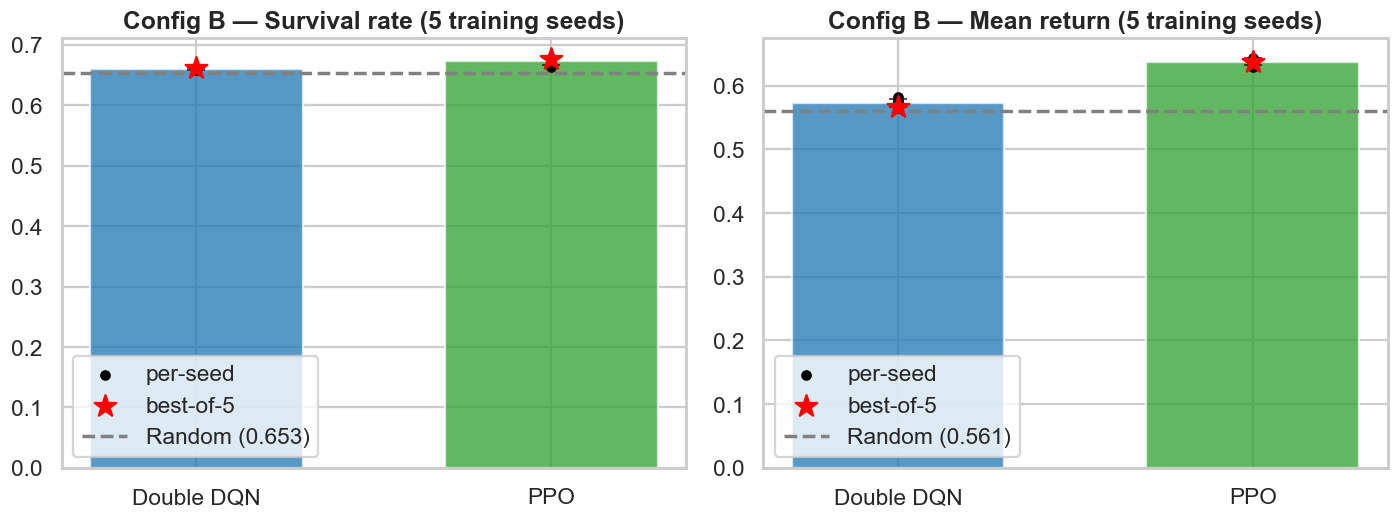

In [30]:
# --- Plot: bar = mean across seeds (error bar = std), dots = the 5 seeds, star = best-of-5 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
algos, labels, colors = ['ddqn', 'ppo'], ['Double DQN', 'PPO'], [BLUE, GREEN]

panels = [(axes[0], 'test_survival_rate', RANDOM_REF['surv'],   'best_surv', 'Survival rate'),
          (axes[1], 'test_mean_return',   RANDOM_REF['return'], 'best_ret',  'Mean return')]

for ax, metric, ref, best_key, title in panels:
    for i, algo in enumerate(algos):
        sub = multiseed_df[multiseed_df['algo'] == algo]
        m, sd = sub[metric].mean(), sub[metric].std(ddof=1)
        ax.bar(i, m, yerr=sd, capsize=6, color=colors[i], alpha=0.75, width=0.6)
        ax.scatter([i] * len(sub), sub[metric], color='black', s=30, zorder=3,
                   label='per-seed' if i == 0 else None)
        ax.scatter([i], [agg[algo][best_key]], marker='*', color='red', s=220, zorder=4,
                   label='best-of-5' if i == 0 else None)
    ax.axhline(ref, ls='--', color='grey', label=f'Random ({ref:.3f})')
    ax.set_xticks(range(len(algos)))
    ax.set_xticklabels(labels)
    ax.set_title(f'Config B — {title} (5 training seeds)', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configB_multiseed.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the figure.** The bar is the mean over the 5 training seeds and the error bar
is the standard deviation *between* seeds — this is the real measure of robustness. The black
dots are the individual seeds, and the red star is the best-of-5 agent (chosen on the
validation seed) used for the qualitative analyses. If an algorithm's error bar overlaps the
random dashed line, it does **not** reliably beat random across reruns.

In [31]:
# --- Load the best-of-5 agent (selected by validation) for the qualitative analyses ---
def load_best_agent(algo):
    a     = agg[algo]
    tag   = f"{algo}_seed{a['best_seed']}"
    state = torch.load(f'{MULTISEED_DIR}/checkpoints/{tag}.pt', map_location='cpu')
    if algo == 'ddqn':
        ag = DQNAgent(double=True, hidden1=best_params_ddqn['hidden1'],
                      hidden2=best_params_ddqn['hidden2'])
        ag.online_net.load_state_dict(state)
        ag.target_net.load_state_dict(state)
    else:
        ag = PPOAgent(hidden1=best_params_ppo['hidden1'], hidden2=best_params_ppo['hidden2'])
        ag.net.load_state_dict(state)
    return ag

agent_ddqn_best = load_best_agent('ddqn')
agent_ppo_best  = load_best_agent('ppo')
print(f"Loaded best-of-5  |  DDQN seed {agg['ddqn']['best_seed']}  |  PPO seed {agg['ppo']['best_seed']}")
# Use agent_ddqn_best / agent_ppo_best for the policy-disagreement and trajectory plots.

Loaded best-of-5  |  DDQN seed 4  |  PPO seed 3
